# Load libraries

In [23]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DC/H2Integrate')

import numpy as np
import pandas as pd
from h2integrate.core.h2integrate_model import H2IntegrateModel



# Setup H2I model with nuclear + DC yaml file

In [24]:
h2i = H2IntegrateModel("examples/32_nuclear_DC_case_1/nuclear_datacenter_config.yaml")
h2i.setup()

In [25]:
system_capacity = h2i.prob.get_val("plant.nuclear.QuinnNuclearPerformanceModel.system_capacity", units="kW")
print(f"System capacity: {system_capacity[0]:.2f} kW")

System capacity: 1000000.00 kW


## The current setup is:

NPP is connected to he grid (selling all its power to the grid at 0.05/kwh)
The DC buys power from the grid. 

In [ ]:

results = []

for capacity_mw in [500, 750, 1000, 1250, 1500]:
    capacity_kw = capacity_mw * 1000

    h2i.prob.set_val("nuclear.system_capacity",  capacity_kw, units="kW")
    h2i.prob.set_val("grid.interconnection_size", capacity_kw, units="kW")
    h2i.prob.set_val("nuclear.electricity_demand", np.full(8760, capacity_kw), units="kW")
    h2i.prob.set_val("grid.electricity_demand",    np.full(8760, 500_000),    units="kW")

    h2i.run()

    def get(path, units=None):
        v = h2i.prob.get_val(path, units=units) if units else h2i.prob.get_val(path)
        return float(v.flat[0]) if hasattr(v, 'flat') else v

    # ── Performance ──────────────────────────────────────────────────────────
    annual_gwh = get("nuclear.total_electricity_produced", "kW*h") / 1e6

    # ── Raw costs (2024 $, before cost-year adjustment) ───────────────────────
    nuc_capex_b      = get("nuclear.CapEx",      "USD")    / 1e9
    nuc_opex_m       = get("nuclear.OpEx",       "USD/year") / 1e6
    nuc_varopex_m    = get("nuclear.VarOpEx",    "USD/year") / 1e6   # shape-30, take yr-0
    grid_capex_m     = get("grid.CapEx",         "USD")    / 1e6
    grid_opex_m      = get("grid.OpEx",          "USD/year") / 1e6
    grid_revenue_m   = -get("grid.VarOpEx",      "USD/year") / 1e6  # negative → revenue

    # ── Cost-year-adjusted costs (used by ProFAST) ────────────────────────────
    adj_nuc_capex_b  = get("finance_subgroup_nuclear.capex_adjusted_nuclear",  "USD")    / 1e9
    adj_nuc_opex_m   = get("finance_subgroup_nuclear.opex_adjusted_nuclear",   "USD/year") / 1e6
    adj_nuc_vom_m    = get("finance_subgroup_nuclear.varopex_adjusted_nuclear","USD/year") / 1e6
    adj_grid_capex_m = get("finance_subgroup_nuclear.capex_adjusted_grid",     "USD")    / 1e6
    adj_grid_opex_m  = get("finance_subgroup_nuclear.opex_adjusted_grid",      "USD/year") / 1e6
    adj_grid_rev_m   = -get("finance_subgroup_nuclear.varopex_adjusted_grid",  "USD/year") / 1e6
    total_capex_b    = get("finance_subgroup_nuclear.total_capex_adjusted",    "USD")    / 1e9
    total_opex_m     = get("finance_subgroup_nuclear.total_opex_adjusted",     "USD/year") / 1e6
    total_varopex_m  = get("finance_subgroup_nuclear.total_varopex_adjusted",  "USD/year") / 1e6

    # ── ProFAST financial metrics ─────────────────────────────────────────────
    # Note: wacc/crf/irr are stored as fractions; multiply by 100 for %
    lcoe_mwh  = get("finance_subgroup_nuclear.LCOE", "USD/(kW*h)") * 1000
    wacc_pct  = get("finance_subgroup_nuclear.wacc_electricity",                   "percent") * 100
    crf_pct   = get("finance_subgroup_nuclear.crf_electricity",                    "percent") * 100
    irr_pct   = get("finance_subgroup_nuclear.irr_electricity",                    "percent") * 100
    pi        = get("finance_subgroup_nuclear.profit_index_electricity",           "unitless")
    payback   = get("finance_subgroup_nuclear.investor_payback_period_electricity","yr")


    lcoe_breakdown = h2i.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    results.append({
        # config
        "nuclear_mw":          capacity_mw,
        # performance
        "capacity_factor":     get("nuclear.capacity_factor"),
        "annual_elec_gwh":     annual_gwh,
        # raw costs
        "nuc_capex_B$":        nuc_capex_b,
        "nuc_opex_M$/yr":      nuc_opex_m,
        "nuc_varopex_M$/yr":   nuc_varopex_m,
        "grid_capex_M$":       grid_capex_m,
        "grid_opex_M$/yr":     grid_opex_m,
        "grid_revenue_M$/yr":  grid_revenue_m,
        # adjusted costs (ProFAST inputs)
        "adj_nuc_capex_B$":    adj_nuc_capex_b,
        "adj_nuc_opex_M$/yr":  adj_nuc_opex_m,
        "adj_nuc_vom_M$/yr":   adj_nuc_vom_m,
        "adj_grid_capex_M$":   adj_grid_capex_m,
        "adj_grid_opex_M$/yr": adj_grid_opex_m,
        "adj_grid_rev_M$/yr":  adj_grid_rev_m,
        "total_capex_B$":      total_capex_b,
        "total_opex_M$/yr":    total_opex_m,
        "total_net_varopex_M$/yr": total_varopex_m,
        # ProFAST metrics
        "lcoe_$/MWh":          lcoe_mwh,
        "wacc_%":              wacc_pct,
        "crf_%":               crf_pct,
        "irr_%":               irr_pct,
        "profit_index":        pi,
        "payback_yr":          payback,
        # full LCOE breakdown dict (one per row)
        "lcoe_breakdown":      lcoe_breakdown,
    })

df = pd.DataFrame(results)
print(df[["nuclear_mw","lcoe_$/MWh","wacc_%","crf_%","irr_%","profit_index","payback_yr"]].to_string(index=False))


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_

 nuclear_mw  lcoe_$/MWh  wacc_%    crf_%  irr_%  profit_index  payback_yr
        500   69.551121  5.6925 6.650353    6.0      2.507841        14.0
        750   64.555972  5.6925 6.650353    6.0      2.508383        14.0
       1000   61.191653  5.6925 6.650353    6.0      2.508787        14.0
       1250   58.680248  5.6925 6.650353    6.0      2.509113        14.0
       1500   56.689773  5.6925 6.650353    6.0      2.509387        14.0


In [ ]:
=
breakdown_rows = []
for _, row in df.iterrows():
    d = {"nuclear_mw": row["nuclear_mw"]}
    for k, v in row["lcoe_breakdown"].items():
        # Simplify key: strip "LCOE: " prefix and "($/kWh)" suffix
        short = k.replace("LCOE: ", "").replace(" ($/kWh)", "").strip()
        d[short] = v * 1000  # convert $/kWh - $/MWh
    breakdown_rows.append(d)

df_breakdown = pd.DataFrame(breakdown_rows).set_index("nuclear_mw")
print("LCOE breakdown ($/MWh):")
print(df_breakdown.to_string())


LCOE breakdown ($/MWh):
            nuclear CapEx  grid CapEx  nuclear OpEx  grid OpEx  nuclear Feedstock  grid Coproduct     Taxes  Finances      Total
nuclear_mw                                                                                                                      
500             74.736969    1.036257     14.277216   0.543273          16.298192       -47.59072  8.769044  1.480890  69.551121
750             70.335277    1.036380     14.277216   0.543273          16.298192       -47.59072  8.261652  1.394702  64.555972
1000            67.370652    1.036472     14.277216   0.543273          16.298192       -47.59072  7.919915  1.336653  61.191653
1250            65.157608    1.036545     14.277216   0.543273          16.298192       -47.59072  7.664814  1.293320  58.680248
1500            63.403601    1.036607     14.277216   0.543273          16.298192       -47.59072  7.462628  1.258976  56.689773


FileNotFoundError: [Errno 2] No such file or directory: 'examples/32_nuclear_DC_case_1/sweep_visualization.png'

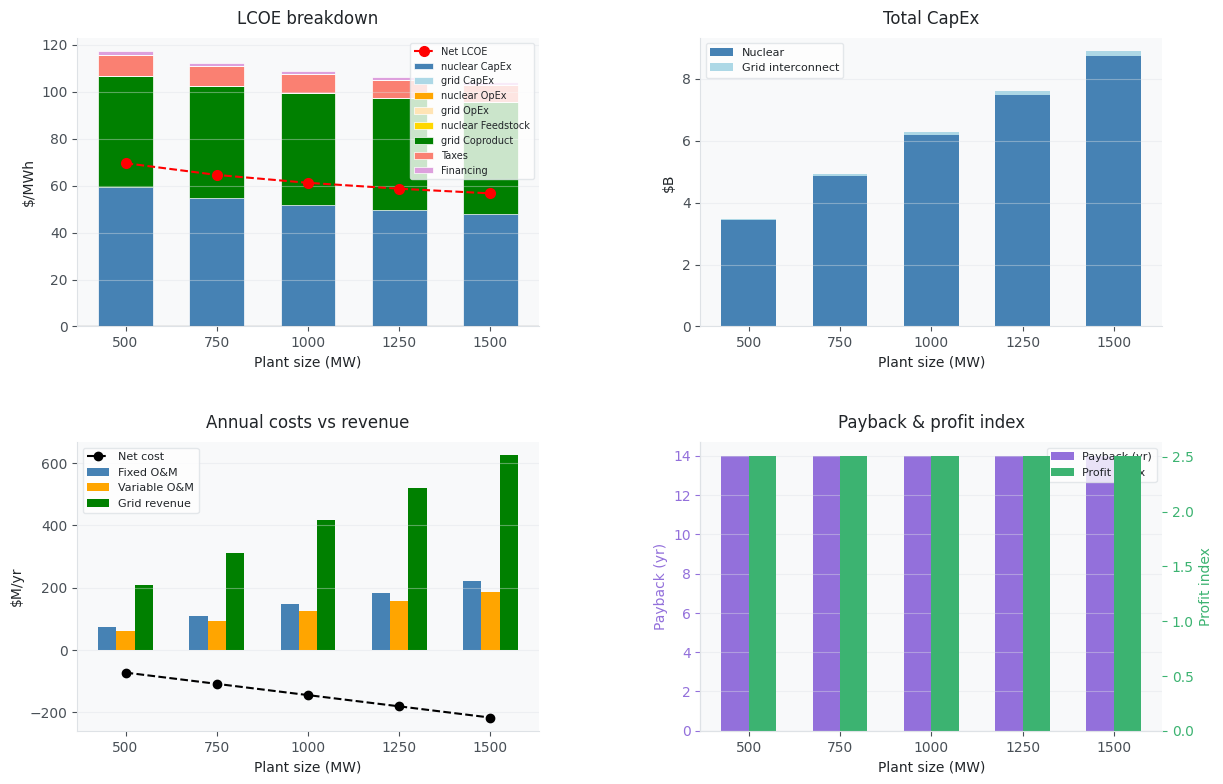

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

sizes  = df["nuclear_mw"].values.astype(float)
labels = [f"{int(s)}" for s in sizes]
x = np.arange(len(sizes))

# -- LCOE breakdown --
ax = axes[0, 0]
cols_colors = []
for col in df_breakdown.columns:
    if "Total" in col:
        continue
    elif "CapEx" in col and "nuclear" in col.lower():
        cols_colors.append((col, "steelblue", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "CapEx" in col and "grid" in col.lower():
        cols_colors.append((col, "lightblue", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "OpEx" in col and "nuclear" in col.lower():
        cols_colors.append((col, "orange", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "OpEx" in col and "grid" in col.lower():
        cols_colors.append((col, "moccasin", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "Feedstock" in col:
        cols_colors.append((col, "gold", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "Coproduct" in col:
        cols_colors.append((col, "green", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "Tax" in col:
        cols_colors.append((col, "salmon", "Taxes"))
    elif "Financ" in col:
        cols_colors.append((col, "plum", "Financing"))

bottom = np.zeros(len(df_breakdown))
for col, color, label in cols_colors:
    vals = df_breakdown[col].values.astype(float)
    pos = np.clip(vals, 0, None)
    neg = np.clip(vals, None, 0)
    ax.bar(x, pos, 0.6, bottom=bottom,        color=color, label=label, edgecolor="white", lw=0.5)
    ax.bar(x, neg, 0.6, bottom=bottom,        color=color, edgecolor="white", lw=0.5)
    bottom = np.where(vals >= 0, bottom + vals, bottom)

ax.plot(x, df["lcoe_$/MWh"].values, "ro--", ms=7, label="Net LCOE")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$/MWh")
ax.set_title("LCOE breakdown")
ax.axhline(0, color="black", lw=0.8)
ax.legend(fontsize=7, loc="upper right")
ax.grid(axis="y", alpha=0.4)

# -- CapEx --
ax = axes[0, 1]
nuc  = df["adj_nuc_capex_B$"].values
grid = df["adj_grid_capex_M$"].values / 1e3
ax.bar(x, nuc,  0.6, color="steelblue", label="Nuclear")
ax.bar(x, grid, 0.6, bottom=nuc, color="lightblue", label="Grid interconnect")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$B")
ax.set_title("Total CapEx")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# -- Annual costs vs revenue --
ax = axes[1, 0]
fom = df["adj_nuc_opex_M$/yr"].values + df["adj_grid_opex_M$/yr"].values
vom = df["adj_nuc_vom_M$/yr"].values
rev = df["adj_grid_rev_M$/yr"].values
net = fom + vom - rev

ax.bar(x - 0.2, fom, 0.2, color="steelblue", label="Fixed O&M")
ax.bar(x,       vom, 0.2, color="orange",    label="Variable O&M")
ax.bar(x + 0.2, rev, 0.2, color="green",     label="Grid revenue")
ax.plot(x, net, "ko--", ms=6, label="Net cost")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$M/yr")
ax.set_title("Annual costs vs revenue")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.4)

# -- Payback & profit index --
ax = axes[1, 1]
ax.bar(x - 0.15, df["payback_yr"].values,  0.3, color="mediumpurple", label="Payback (yr)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("Payback (yr)", color="mediumpurple")
ax.tick_params(axis="y", colors="mediumpurple")

ax2 = ax.twinx()
ax2.bar(x + 0.15, df["profit_index"].values, 0.3, color="mediumseagreen", label="Profit index")
ax2.set_ylabel("Profit index", color="mediumseagreen")
ax2.tick_params(axis="y", colors="mediumseagreen")

ax.set_title("Payback & profit index")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2, l1+l2, fontsize=8)
ax.grid(axis="y", alpha=0.4)

plt.show()
